In [1]:
import os

# 获取当前 PATH 并追加新路径
new_path = "/root/autodl-tmp/water/defects4j/framework/bin"
os.environ['PATH'] = os.environ['PATH'] + ":" + new_path
print("Updated PATH:", os.environ['PATH'])
# 验证
!defects4j info -p Lang

Updated PATH: /root/miniconda3/envs/water/bin:/root/.vscode-server/cli/servers/Stable-2901c5ac6db8a986a5666c3af51ff804d05af0d4/server/bin/remote-cli:/root/.nvm/versions/node/v24.14.1/bin:/root/miniconda3/envs/water/bin:/root/miniconda3/condabin:/root/miniconda3/bin:/usr/local/bin:/root/miniconda3/bin:/usr/local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/root/autodl-tmp/water/defects4j/framework/bin
Summary of configuration for Project: Lang
--------------------------------------------------------------------------------
    Script dir: /root/autodl-tmp/water/defects4j/framework
      Base dir: /root/autodl-tmp/water/defects4j
    Major root: /root/autodl-tmp/water/defects4j/major
      Repo dir: /root/autodl-tmp/water/defects4j/project_repos
--------------------------------------------------------------------------------
    Project ID: Lang
       Program: commons-lang
    Build file: /root/autodl-tmp/water/defects4j/framewo

| **功能模块**       | **命令**       | **详细解析 (Description & Deep Dive)**                       | **常用场景举例**           |
| ------------------ | -------------- | ------------------------------------------------------------ | -------------------------- |
| **基础信息查询**   | `pids`         | **列出项目 ID**。显示所有受支持的项目（如 Chart, Ghost, Lang, Math 等）。 | 确认环境是否安装成功       |
|                    | `bids`         | **列出 Bug ID**。针对特定项目（需 `-p` 参数）列出所有活跃或已弃用的缺陷编号。 | `bids -p Lang`             |
|                    | `info`         | **查看详细配置/摘要**。查看特定项目或特定 Bug 的详细元数据（如受影响的类、触发测试等）。 | `info -p Math -b 1`        |
| **工作空间准备**   | `checkout`     | **检出项目版本**。根据 Bug ID 检出 `bgy` (buggy) 或 `fxd` (fixed) 版本的源码到指定目录。 | **数据准备的第一步**       |
|                    | `env`          | **打印环境变量**。显示执行 Defects4J 时相关的 Java 路径、类路径等环境配置。 | 调试环境配置错误时使用     |
| **构建与验证**     | `compile`      | **编译代码**。编译检出的源码和开发人员编写的测试用例。       | 运行测试前的必要步骤       |
|                    | `test`         | **运行测试**。可以运行整个测试集，也可以运行单个测试方法。   | 验证 Bug 是否被触发或修复  |
|                    | `export`       | **导出属性**。导出特定版本的类路径（Classpath）、源代码目录或测试列表。 | 获取编译依赖以辅助静态分析 |
| **质量与覆盖分析** | `coverage`     | **覆盖率分析**。运行测试并统计代码覆盖率（通常使用 Cobertura 或 JaCoCo）。 | 评估测试集的完备性         |
|                    | `mutation`     | **变异分析**。运行变异测试（PIT），通过植入人工 Bug 评估测试集的检测能力。 | 评估测试套件的“杀伤力”     |
|                    | `monitor.test` | **类加载监控**。在测试执行期间监控类加载器，识别测试过程中实际加载的类。 | 精确识别测试相关的类依赖   |
| **数据批量导出**   | `query`        | **元数据查询**。支持根据指定字段（如 `bug.id`, `cve.id`）批量生成 CSV 格式的项目数据。 | **批量提取特征时使用**     |

------

In [ ]:
import os
import subprocess
import json
import javalang

# --- 配置区域 ---
PROJECTS = ["Lang", "Math", "Chart"] # 可以添加 ["Lang", "Math", "Chart"]
BUG_RANGE = range(1, 3)  # 示例：提取每个项目的前 2 个 Bug
OUTPUT_FILE = "defects4j_code_comment_dataset.jsonl"
WORKSPACE_BASE = "./temp_workspace"

def run_command(cmd, cwd=None):
    """执行 Shell 命令并返回结果"""
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    return result.stdout

def extract_methods_with_comments(java_source):
    """解析 Java 源码，提取注释和对应的方法体"""
    dataset = []
    try:
        tree = javalang.parse.parse(java_source)
        lines = java_source.splitlines()
        
        for _, node in tree.filter(javalang.tree.MethodDeclaration):
            # 1. 提取 Javadoc (如果有)
            comment = node.documentation if node.documentation else ""
            
            # 2. 提取方法体 (基于行号定位)
            start_line = node.position.line
            # 粗略计算方法结束位置（javalang 并不直接提供结束行，此处为简化示例）
            # 实际生产中建议使用 Tree-sitter 获得更精确的范围
            end_line = start_line
            bracket_count = 0
            started = False
            for i in range(start_line - 1, len(lines)):
                line = lines[i]
                bracket_count += line.count('{')
                bracket_count -= line.count('}')
                if '{' in line: started = True
                if started and bracket_count <= 0:
                    end_line = i + 1
                    break
            
            method_code = "\n".join(lines[start_line-1:end_line])
            
            if comment: # 仅保留有注释的方法
                dataset.append({
                    "comment": comment.strip(),
                    "code": method_code.strip()
                })
    except Exception as e:
        pass # 忽略解析失败的文件
    return dataset

# --- 主循环 ---
if not os.path.exists(WORKSPACE_BASE): os.makedirs(WORKSPACE_BASE)

with open(OUTPUT_FILE, 'w', encoding='utf-8') as f_out:
    for proj in PROJECTS:
        for b_id in BUG_RANGE:
            work_dir = os.path.join(WORKSPACE_BASE, f"{proj}_{b_id}")
            print(f"正在处理: {proj} Bug-{b_id}...")
            
            # 1. Checkout 固定版本 (f 表示 Fixed 版本)
            run_command(f"defects4j checkout -p {proj} -v {b_id}f -w {work_dir}")
            
            # 2. 遍历检出目录中的所有 .java 文件
            for root, _, files in os.walk(work_dir):
                for file in files:
                    if file.endswith(".java") and "test" not in root.lower():
                        file_path = os.path.join(root, file)
                        with open(file_path, 'r', encoding='latin-1') as f_in:
                            content = f_in.read()
                            pairs = extract_methods_with_comments(content)
                            for pair in pairs:
                                pair['project'] = proj
                                pair['bug_id'] = b_id
                                f_out.write(json.dumps(pair) + "\n")
            
            # 3. 清理空间 (可选)
            # os.system(f"rm -rf {work_dir}")

print(f"数据集已生成至: {OUTPUT_FILE}")

In [ ]:
!java -version
!defects4j env

In [ ]:
import os
import subprocess

# 强制指定 Java 8 路径 (请根据你系统实际路径修改)


def test_checkout():
    proj = "Lang"
    b_id = "1"
    work_dir = "./test_lang_1"
    
    # 尝试检出
    cmd = f"defects4j checkout -p {proj} -v {b_id}f -w {work_dir}"
    print(f"执行命令: {cmd}")
    
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    if res.returncode == 0:
        print("✅ 检出成功！SVN 和 Java 环境现在正常了。")
    else:
        print("❌ 检出失败。")
        print(f"标准输出: {res.stdout}")
        print(f"错误输出: {res.stderr}")

test_checkout()


In [ ]:
import os
import subprocess
import json
import javalang
import shutil

# --- 配置区域 ---
PROJECTS = ["Lang", "Math"]  # 环境通了可以多跑几个项目
BUG_IDS = [str(i) for i in range(1, 11)]  # 示例：每个项目跑前10个Bug
WORKSPACE_ROOT = "../dataset/d4j_workspace"
OUTPUT_FILE = "../dataset/d4j_dataset_b_and_f.jsonl"

# 确保 Java 8 环境在脚本内生效 (针对 AutoDL 等环境)
java8_path = "/usr/lib/jvm/java-8-openjdk-amd64"
if os.path.exists(java8_path):
    os.environ["JAVA_HOME"] = java8_path
    os.environ["PATH"] = f"{java8_path}/bin:" + os.environ["PATH"]

def get_method_map(src_path):
    """解析 Java 文件，提取 (方法签名: {注释, 代码})"""
    methods = {}
    if not os.path.exists(src_path): return methods
    try:
        with open(src_path, 'r', encoding='latin-1') as f:
            content = f.read()
        tree = javalang.parse.parse(content)
        lines = content.splitlines()
        
        for _, node in tree.filter(javalang.tree.MethodDeclaration):
            m_name = node.name
            param_types = [p.type.name for p in node.parameters]
            m_sig = f"{m_name}({','.join(param_types)})" # 使用签名处理重载
            
            start = node.position.line
            # 找到方法的结束行
            end = start
            brace_count = 0
            for i in range(start - 1, len(lines)):
                line = lines[i]
                brace_count += line.count('{')
                brace_count -= line.count('}')
                if brace_count <= 0 and '{' in "".join(lines[start-1:i+1]):
                    end = i + 1
                    break
            
            methods[m_sig] = {
                "comment": node.documentation if node.documentation else "",
                "code": "\n".join(lines[start-1:end]).strip()
            }
    except:
        pass
    return methods

# --- 主逻辑 ---
if os.path.exists(WORKSPACE_ROOT): shutil.rmtree(WORKSPACE_ROOT)
os.makedirs(WORKSPACE_ROOT)

print(f"🚀 开始构建数据集，预定处理 {len(PROJECTS) * len(BUG_IDS)} 个 Bug 实例...")

with open(OUTPUT_FILE, 'w', encoding='utf-8') as f_out:
    for proj in PROJECTS:
        for b_id in BUG_IDS:
            p_b = os.path.join(WORKSPACE_ROOT, f"{proj}_{b_id}b")
            p_f = os.path.join(WORKSPACE_ROOT, f"{proj}_{b_id}f")
            
            # 1. Checkout b 和 f 版本
            res_b = subprocess.run(f"defects4j checkout -p {proj} -v {b_id}b -w {p_b}", shell=True, capture_output=True)
            res_f = subprocess.run(f"defects4j checkout -p {proj} -v {b_id}f -w {p_f}", shell=True, capture_output=True)
            
            if res_b.returncode != 0 or res_f.returncode != 0:
                print(f"⚠️ 跳过 {proj}-{b_id}: Checkout 失败")
                continue

            # 2. 获取该 Bug 修改了哪些类
            try:
                mod_classes = subprocess.check_output("defects4j export -p classes.modified", 
                                                      shell=True, cwd=p_b, text=True).strip().splitlines()
            except: continue

            # 3. 对比方法差异
            found_count = 0
            for clazz in mod_classes:
                rel_path = clazz.replace('.', '/') + ".java"
                # 寻找文件实际位置 (兼容不同项目的目录结构)
                file_b = next((os.path.join(r, f_file) for r, _, fs in os.walk(p_b) for f_file in fs if f_file == os.path.basename(rel_path)), None)
                if not file_b: continue
                file_f = file_b.replace(f"{proj}_{b_id}b", f"{proj}_{b_id}f")

                methods_b = get_method_map(file_b)
                methods_f = get_method_map(file_f)

                for sig, data_f in methods_f.items():
                    if sig in methods_b and data_f['code'] != methods_b[sig]['code']:
                        # 发现被修改的方法！这就是我们要的数据对
                        record = {
                            "project": proj,
                            "bug_id": b_id,
                            "class": clazz,
                            "method": sig,
                            "comment": data_f['comment'],
                            "buggy_code": methods_b[sig]['code'],
                            "fixed_code": data_f['code']
                        }
                        f_out.write(json.dumps(record, ensure_ascii=False) + "\n")
                        found_count += 1
            
            print(f"✅ {proj}-{b_id}: 提取到 {found_count} 个修改方法")
            
            # 4. 可选：处理完删除工作区以节省空间
            shutil.rmtree(p_b); shutil.rmtree(p_f)

print(f"\n✨ 数据集构建完成！结果保存在: {OUTPUT_FILE}")

In [8]:
!defects4j pids
!defects4j checkout -p Chart -v 1f -w ./test_chart


Chart
Cli
Closure
Codec
Collections
Compress
Csv
Gson
JacksonCore
JacksonDatabind
JacksonXml
Jsoup
JxPath
Lang
Math
Mockito
Time
Checking out 2266 to /root/autodl-tmp/water/scripts/test_chart............. svn: E170013: Unable to connect to a repository at URL 'file:///root/autodl-tmp/water/defects4j/project_repos/jfreechart/trunk'
svn: E180001: Unable to open repository 'file:///root/autodl-tmp/water/defects4j/project_repos/jfreechart/trunk'
FAIL
Executed command: svn -r 2266 co file:///root/autodl-tmp/water/defects4j/project_repos/jfreechart/trunk /root/autodl-tmp/water/scripts/test_chart
Cannot checkout program version! at /root/autodl-tmp/water/defects4j/framework/bin/d4j/d4j-checkout line 96.
Compilation failed in require at /root/autodl-tmp/water/defects4j/framework/bin/defects4j line 195.


In [13]:
import os
import subprocess
import json
import javalang
import shutil

# --- 配置区域 ---
# 包含所有你想收集的项目
PROJECTS = [ "Time", "Lang", "Math", "Closure", "Mockito", "Cli", "Codec", "Collections", "Compress", "Csv", "Gson", "JacksonCore", "JacksonDatabind", "JacksonXml", "Jsoup", "JxPath", "Mockito"]
WORKSPACE_ROOT = "../dataset/d4j_workspace"
OUTPUT_FILE = "../dataset/d4j_full_dataset.jsonl"

# 确保 Java 8 环境
java8_path = "/usr/lib/jvm/java-8-openjdk-amd64"
if os.path.exists(java8_path):
    os.environ["JAVA_HOME"] = java8_path
    os.environ["PATH"] = f"{java8_path}/bin:" + os.environ["PATH"]

def get_method_map(src_path):
    """解析 Java 文件，提取 (方法签名: {注释, 代码})"""
    methods = {}
    if not os.path.exists(src_path): return methods
    try:
        with open(src_path, 'r', encoding='latin-1') as f:
            content = f.read()
        tree = javalang.parse.parse(content)
        lines = content.splitlines()
        
        for _, node in tree.filter(javalang.tree.MethodDeclaration):
            m_name = node.name
            param_types = [getattr(p.type, 'name', 'Unknown') for p in node.parameters]
            m_sig = f"{m_name}({','.join(param_types)})"
            
            start = node.position.line
            end = start
            brace_count = 0
            for i in range(start - 1, len(lines)):
                line = lines[i]
                brace_count += line.count('{')
                brace_count -= line.count('}')
                if brace_count <= 0 and '{' in "".join(lines[start-1:i+1]):
                    end = i + 1
                    break
            
            methods[m_sig] = {
                "comment": node.documentation if node.documentation else "",
                "code": "\n".join(lines[start-1:end]).strip()
            }
    except:
        pass
    return methods

# --- 主逻辑 ---
if os.path.exists(WORKSPACE_ROOT): shutil.rmtree(WORKSPACE_ROOT)
os.makedirs(WORKSPACE_ROOT, exist_ok=True)

print(f"🚀 开始全量构建数据集...")

with open(OUTPUT_FILE, 'w', encoding='utf-8') as f_out:
    for proj in PROJECTS:
        # 动态获取当前项目所有的 Bug ID
        print(f"\n[项目: {proj}] 正在获取 Bug 列表...")
        try:
            bids_str = subprocess.check_output(f"defects4j bids -p {proj}", shell=True, text=True)
            bug_ids = bids_str.strip().splitlines()
        except Exception as e:
            print(f"❌ 无法获取项目 {proj} 的 bids: {e}")
            continue

        for b_id in bug_ids:
            p_b = os.path.join(WORKSPACE_ROOT, f"{proj}_{b_id}b")
            p_f = os.path.join(WORKSPACE_ROOT, f"{proj}_{b_id}f")
            
            # 1. Checkout
            res_b = subprocess.run(f"defects4j checkout -p {proj} -v {b_id}b -w {p_b}", shell=True, capture_output=True)
            res_f = subprocess.run(f"defects4j checkout -p {proj} -v {b_id}f -w {p_f}", shell=True, capture_output=True)
            
            if res_b.returncode != 0 or res_f.returncode != 0:
                print(f"  ⚠️ 跳过 {proj}-{b_id}: Checkout 失败 (可能该版本已弃用)")
                if os.path.exists(p_b): shutil.rmtree(p_b)
                if os.path.exists(p_f): shutil.rmtree(p_f)
                continue

            # 2. 获取变更类
            try:
                mod_classes = subprocess.check_output("defects4j export -p classes.modified", 
                                                      shell=True, cwd=p_b, text=True).strip().splitlines()
            except: 
                shutil.rmtree(p_b); shutil.rmtree(p_f)
                continue

            # 3. 对比方法差异
            found_count = 0
            for clazz in mod_classes:
                rel_path = clazz.replace('.', '/') + ".java"
                target_filename = os.path.basename(rel_path)
                
                file_b = None
                for r, _, fs in os.walk(p_b):
                    if target_filename in fs:
                        potential_path = os.path.join(r, target_filename)
                        if potential_path.endswith(rel_path):
                            file_b = potential_path
                            break
                
                if not file_b: continue
                file_f = file_b.replace(p_b, p_f)
                if not os.path.exists(file_f): continue

                methods_b = get_method_map(file_b)
                methods_f = get_method_map(file_f)

                for sig, data_f in methods_f.items():
                    if sig in methods_b and data_f['code'] != methods_b[sig]['code']:
                        record = {
                            "project": proj,
                            "bug_id": b_id,
                            "class": clazz,
                            "method": sig,
                            "comment": data_f['comment'],
                            "buggy_code": methods_b[sig]['code'],
                            "fixed_code": data_f['code']
                        }
                        f_out.write(json.dumps(record, ensure_ascii=False) + "\n")
                        found_count += 1
            
            print(f"  ✅ {proj}-{b_id}: 提取到 {found_count} 个修改方法")
            shutil.rmtree(p_b); shutil.rmtree(p_f)

print(f"\n✨ 全量数据集构建完成！结果保存在: {OUTPUT_FILE}")

🚀 开始全量构建数据集...

[项目: Time] 正在获取 Bug 列表...


Running ant (export.classes.modified)...................................... OK



  ✅ Time-1: 提取到 1 个修改方法


Running ant (export.classes.modified)...................................... OK



  ✅ Time-2: 提取到 2 个修改方法


...

Running ant (export.classes.modified)...................................... OK



  ✅ Mockito-37: 提取到 1 个修改方法


Running ant (export.classes.modified)...................................... 

  ✅ Mockito-38: 提取到 1 个修改方法

✨ 全量数据集构建完成！结果保存在: ../dataset/d4j_full_dataset.jsonl


OK



In [17]:
import json
import os
import re

# --- 配置 ---
INPUT_FILE = "../dataset/d4j_full_dataset.jsonl"
OUTPUT_FILE = "../dataset/d4j_enhanced_dataset.jsonl"

def extract_inline_comments(code_text):
    """
    从代码字符串中提取所有单行 (//) 和多行 (/* */) 注释
    """
    # 匹配 // 注释和 /* ... */ 注释
    pattern = r'(?://[^\n]*|/\*.*?\*/)'
    inline_comments = re.findall(pattern, code_text, re.DOTALL)
    
    # 清洗注释符号，只保留文字内容
    cleaned_comments = []
    for c in inline_comments:
        c = re.sub(r'(^//|^/\*|\*/$)', '', c).strip()
        c = re.sub(r'^\s*\*\s?', '', c, flags=re.MULTILINE) # 去除多行注释前面的星号
        if c:
            cleaned_comments.append(c)
    
    return " ".join(cleaned_comments)

def process_and_merge_comments(input_path, output_path):
    processed_count = 0
    skipped_count = 0

    if not os.path.exists(input_path):
        print(f"❌ 错误：找不到源文件 {input_path}")
        return

    print(f"🔄 正在提取代码内注释并合并...")

    with open(input_path, 'r', encoding='utf-8') as f_in, \
         open(output_path, 'w', encoding='utf-8') as f_out:
        
        for line in f_in:
            try:
                data = json.loads(line)
                
                # 1. 原始 Javadoc
                javadoc = data.get("comment", "").strip()
                
                # 2. 从 buggy_code 和 fixed_code 中提取内部注释（取并集）
                # 通常两个版本的内部注释差异不大，合并后能提供更完整的语义
                inline_b = extract_inline_comments(data.get("buggy_code", ""))
                inline_f = extract_inline_comments(data.get("fixed_code", ""))
                
                # 合并所有注释：Javadoc + 内部注释
                # 使用 set 去重，防止相同的内部注释被重复添加
                all_inline = " ".join(list(set([inline_b, inline_f])))
                final_comment = (javadoc + " " + all_inline).strip()
                
                # 3. 核心筛查：添加后再筛除空注释
                if not final_comment:
                    skipped_count += 1
                    continue
                
                # 4. 构建基础信息
                base_info = {
                    "project": data.get("project"),
                    "bug_ids": int(data.get("bug_id", 0)),
                    "class": data.get("class"),
                    "method": data.get("method"),
                    "comment": final_comment
                }

                # 5. 拆分正负例
                # Buggy 版本
                buggy_item = base_info.copy()
                buggy_item["code"] = data.get("buggy_code", "").strip()
                buggy_item["is_bug"] = True
                
                # Fixed 版本
                fixed_item = base_info.copy()
                fixed_item["code"] = data.get("fixed_code", "").strip()
                fixed_item["is_bug"] = False

                # 写入
                f_out.write(json.dumps(buggy_item, ensure_ascii=False) + "\n")
                f_out.write(json.dumps(fixed_item, ensure_ascii=False) + "\n")
                
                processed_count += 2
                
            except Exception as e:
                continue

    print(f"\n✨ 增强版数据集构建完成！")
    print(f"📊 最终记录数: {processed_count}")
    print(f"🧹 因完全无注释被筛除的样本: {skipped_count}")
    print(f"📁 存储位置: {output_path}")

# 执行
process_and_merge_comments(INPUT_FILE, OUTPUT_FILE)

🔄 正在提取代码内注释并合并...

✨ 增强版数据集构建完成！
📊 最终记录数: 2110
🧹 因完全无注释被筛除的样本: 219
📁 存储位置: ../dataset/d4j_enhanced_dataset.jsonl


📦 已将以下项目同化为 'etc': ['Collections', 'Time', 'Gson', 'Codec', 'JxPath', 'Csv', 'JacksonXml']


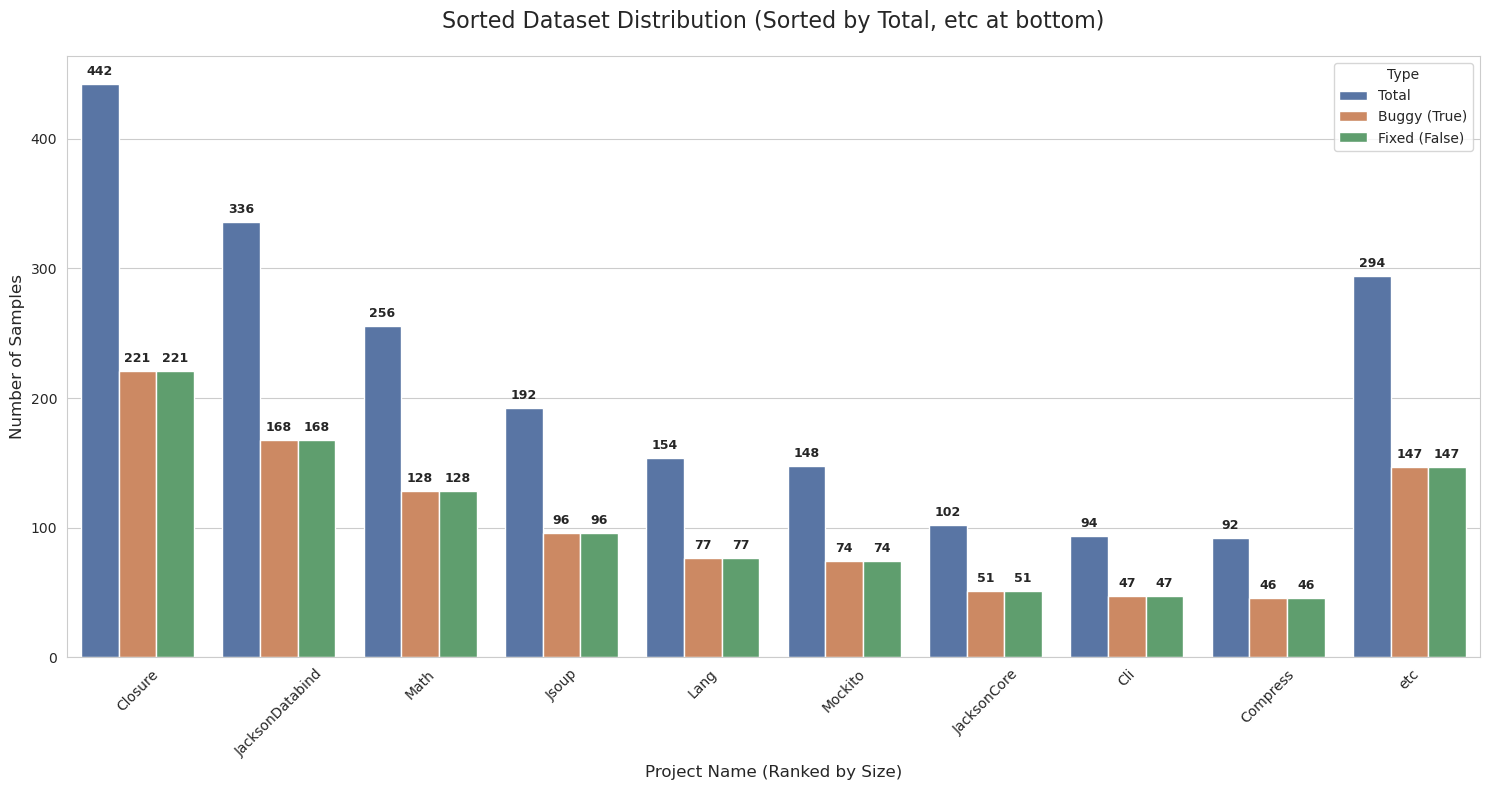

✅ 统计图表已保存至: /root/autodl-tmp/water/dataset/dataset_statistics.png


<Figure size 640x480 with 0 Axes>


=== 排序后的统计报表 ===
                 Fixed (False)  Buggy (True)  Total
Closure                    221           221    442
JacksonDatabind            168           168    336
Math                       128           128    256
Jsoup                       96            96    192
Lang                        77            77    154
Mockito                     74            74    148
JacksonCore                 51            51    102
Cli                         47            47     94
Compress                    46            46     92
etc                        147           147    294


In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 配置 ---
INPUT_FILE = "../dataset/d4j_enhanced_dataset.jsonl"
SAVE_PATH = "../dataset/dataset_statistics.png"  # 图片保存路径

def analyze_sorted_with_etc(file_path,SAVE_PATH, threshold=80):
    if not os.path.exists(file_path):
        print(f"❌ 找不到文件: {file_path}")
        return

    # 1. 加载数据
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    df = pd.DataFrame(data)
    
    # 2. 基础统计
    stats = df.groupby(['project', 'is_bug']).size().unstack(fill_value=0)
    stats.columns = ['Fixed (False)', 'Buggy (True)']
    stats['Total'] = stats['Fixed (False)'] + stats['Buggy (True)']
    
    # 3. 排序与 etc 同化
    # 首先按 Total 降序排列所有项目
    stats = stats.sort_values(by='Total', ascending=False)
    
    minor_projects = stats[stats['Total'] < threshold]
    major_projects = stats[stats['Total'] >= threshold].copy()
    
    if not minor_projects.empty:
        etc_data = minor_projects.sum()
        etc_df = pd.DataFrame([etc_data], index=['etc'])
        # 将大项目排序后，etc 拼接到末尾
        final_stats = pd.concat([major_projects, etc_df])
        print(f"📦 已将以下项目同化为 'etc': {list(minor_projects.index)}")
    else:
        final_stats = major_projects

    # 4. 转换格式用于绘图
    plot_df = final_stats.reset_index().rename(columns={'index': 'project'})
    plot_df = plot_df.melt(id_vars='project', 
                           value_vars=['Total', 'Buggy (True)', 'Fixed (False)'],
                           var_name='Type', value_name='Count')

    # 5. 绘图
    plt.figure(figsize=(15, 8))
    sns.set_style("whitegrid")
    
    # 保持排序顺序：使用 final_stats 的索引作为 x 轴的顺序
    palette = {"Total": "#4C72B0", "Buggy (True)": "#DD8452", "Fixed (False)": "#55A868"}
    
    ax = sns.barplot(data=plot_df, x='project', y='Count', hue='Type', 
                    palette=palette, order=final_stats.index)
    
    # 细节美化
    plt.title(f'Sorted Dataset Distribution (Sorted by Total, etc at bottom)', fontsize=16, pad=20)
    plt.xlabel('Project Name (Ranked by Size)', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45) # 如果项目名长，旋转一下
    
    # 数值标注
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(format(height, '.0f'), 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 9), 
                        textcoords='offset points',
                        fontsize=9, fontweight='bold')

    plt.tight_layout()
    # 6. 保存图片
    plt.savefig(SAVE_PATH, bbox_inches='tight')
    print(f"✅ 统计图表已保存至: {os.path.abspath(SAVE_PATH)}")
    
    # 显示预览
    plt.show()

    print("\n=== 排序后的统计报表 ===")
    print(final_stats)

# 执行
analyze_sorted_with_etc(INPUT_FILE, SAVE_PATH,threshold=80)

In [ ]:
import json

def add_lang_to_jsonl(input_file, output_file):
    """
    针对 JSONL 文件，在每一行的对象首位添加 "lang": "java" 字段。
    """
    try:
        with open(input_file, 'r', encoding='utf-8') as infile, \
             open(output_file, 'w', encoding='utf-8') as outfile:
            
            for line_number, line in enumerate(infile, 1):
                line = line.strip()
                if not line:
                    continue
                
                try:
                    # 解析原始 JSON
                    data = json.loads(line)
                    
                    # 构造新字典：将 lang 放在第一位，再解构原始数据
                    # Python 3.7+ 会严格保持字典插入顺序
                    new_data = {"lang": "java", **data}
                    
                    # 写入新文件，ensure_ascii=False 保证中文/换行符显示正常
                    json_line = json.dumps(new_data, ensure_ascii=False)
                    outfile.write(json_line + '\n')
                    
                except json.JSONDecodeError:
                    print(f"跳过第 {line_number} 行：无效的 JSON 格式")

        print(f"处理完成！已保存至: {output_file}")

    except FileNotFoundError:
        print(f"错误：未找到文件 {input_file}")
    except Exception as e:
        print(f"发生错误: {e}")

# --- 执行设置 ---
input_filename = "../dataset/d4j_enhanced_dataset.jsonl"      # 你的原始文件名
output_filename = "../dataset/data_fixed.jsonl" # 处理后的文件名

add_lang_to_jsonl(input_filename, output_filename)

处理完成！已保存至: data_fixed.jsonl


In [8]:
import json
from collections import Counter

def filter_jsonl(input_file, output_file):
    # 第一步：统计每个 project 出现的次数
    project_counts = Counter()
    
    print("正在扫描项目频率...")
    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    data = json.loads(line)
                    project_name = data.get("project")
                    if project_name:
                        project_counts[project_name] += 1
                except json.JSONDecodeError:
                    continue

    # 第二步：执行过滤并写入
    print("正在执行过滤并生成新文件...")
    keep_count = 0
    total_count = 0
    
    with open(input_file, 'r', encoding='utf-8') as infile, \
         open(output_file, 'w', encoding='utf-8') as outfile:
        
        for line in infile:
            line = line.strip()
            if not line:
                continue
                
            try:
                data = json.loads(line)
                total_count += 1
                
                # 条件 1: project 总数必须 >= 100
                project_name = data.get("project")
                if project_counts[project_name] < 100:
                    continue
                
                # 条件 2: comment 长度必须 >= 10
                comment = data.get("comment", "")
                if len(comment) < 10:
                    continue
                
                # 满足所有条件，写入
                # 顺便确保 "lang": "java" 在最前面（延续之前的需求）
                new_data = {"lang": "java", **data}
                outfile.write(json.dumps(new_data, ensure_ascii=False) + '\n')
                keep_count += 1
                
            except json.JSONDecodeError:
                continue

    print("-" * 30)
    print(f"处理完成！")
    print(f"原始记录数: {total_count}")
    print(f"保留记录数: {keep_count}")
    print(f"过滤掉记录: {total_count - keep_count}")
    print(f"保存路径: {output_file}")

# --- 执行 ---
input_path = "../dataset/codocbench_formatted_mutated.jsonl"
output_path = "../dataset/filtered_data.jsonl"
filter_jsonl(input_path, output_path)

正在扫描项目频率...
正在执行过滤并生成新文件...
------------------------------
处理完成！
原始记录数: 9146
保留记录数: 5436
过滤掉记录: 3710
保存路径: ../dataset/filtered_data.jsonl


In [9]:
import json
from collections import Counter

def merge_and_filter_jsonls(file1, file2, output_file):
    input_files = [file1, file2]
    
    # 1. 第一遍扫描：统计所有文件中 project 的总频率
    project_counts = Counter()
    print("正在预扫描所有文件以统计 project 频率...")
    
    for file_path in input_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        data = json.loads(line)
                        p_name = data.get("project")
                        if p_name:
                            project_counts[p_name] += 1
                    except json.JSONDecodeError:
                        continue

    # 2. 第二遍扫描：合并并执行过滤逻辑
    print(f"开始合并并过滤数据...")
    total_written = 0
    
    with open(output_file, 'w', encoding='utf-8') as outfile:
        for file_path in input_files:
            with open(file_path, 'r', encoding='utf-8') as infile:
                for line in infile:
                    line = line.strip()
                    if not line:
                        continue
                    
                    try:
                        data = json.loads(line)
                        
                        # 过滤逻辑 A: project 总数 < 10 的删除
                        p_name = data.get("project")
                        if project_counts[p_name] < 10:
                            continue
                        
                        # 过滤逻辑 B: comment 长度 < 10 的删除
                        comment = data.get("comment", "")
                        if len(comment) < 10:
                            continue
                        
                        # 统一添加 lang 字段并保持在首位
                        final_item = {"lang": "java", **data}
                        
                        # 写入合并后的文件
                        outfile.write(json.dumps(final_item, ensure_ascii=False) + '\n')
                        total_written += 1
                        
                    except json.JSONDecodeError:
                        continue

    print("-" * 30)
    print(f"合并完成！共计保留记录: {total_written}")
    print(f"输出文件: {output_file}")

# --- 执行设置 ---
file_a = "../dataset/data_fixed.jsonl"
file_b = "../dataset/filtered_data.jsonl"
combined_file = "../dataset/merged_data.jsonl"

merge_and_filter_jsonls(file_a, file_b, combined_file)

正在预扫描所有文件以统计 project 频率...
开始合并并过滤数据...
------------------------------
合并完成！共计保留记录: 7532
输出文件: ../dataset/merged_data.jsonl


In [10]:
import json
from collections import defaultdict

def analyze_jsonl_stats(file_path):
    # 初始化统计结构
    # stats 的结构为: { "java": { "project_name": count }, "python": { ... } }
    stats = defaultdict(lambda: defaultdict(int))
    total_records = 0

    print(f"正在读取文件: {file_path} ...\n")

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                try:
                    data = json.loads(line)
                    total_records += 1
                    
                    lang = data.get("lang", "unknown")
                    project = data.get("project", "unknown")
                    
                    # 计数
                    stats[lang][project] += 1
                    
                except json.JSONDecodeError:
                    continue

        # --- 输出统计结果 ---
        print("=" * 40)
        print(f"数据总条数: {total_records}")
        print("=" * 40)

        for lang, projects in stats.items():
            lang_total = sum(projects.values())
            print(f"\n[语言: {lang.upper()}] - 总计: {lang_total} 条")
            print(f"{'项目名称':<25} | {'条数':<10}")
            print("-" * 40)
            
            # 按项目条数从高到低排序显示
            sorted_projects = sorted(projects.items(), key=lambda x: x[1], reverse=True)
            for p_name, p_count in sorted_projects:
                print(f"{p_name:<25} | {p_count:<10}")

    except FileNotFoundError:
        print(f"错误：找不到文件 {file_path}")
    except Exception as e:
        print(f"发生错误: {e}")

# --- 执行统计 ---
# 请确保文件名与你合并或过滤后的文件名一致
target_file = "../dataset/merged_data.jsonl" 
analyze_jsonl_stats(target_file)

正在读取文件: ../dataset/merged_data.jsonl ...

数据总条数: 7532

[语言: JAVA] - 总计: 2096 条
项目名称                      | 条数        
----------------------------------------
Closure                   | 442       
JacksonDatabind           | 336       
Math                      | 256       
Jsoup                     | 186       
Lang                      | 154       
Mockito                   | 148       
JacksonCore               | 102       
Cli                       | 94        
Compress                  | 92        
Collections               | 78        
Time                      | 66        
Gson                      | 46        
Codec                     | 38        
JxPath                    | 30        
Csv                       | 28        

[语言: PYTHON] - 总计: 5436 条
项目名称                      | 条数        
----------------------------------------
pandas                    | 602       
matplotlib                | 600       
core                      | 326       
pytorch                   | 302 